# CornGuard 02: Evaluasi dan Ekspor Model YOLOv8 (Bulai)

Notebook ini **tidak melatih ulang**. Ia memuat `best.pt` hasil notebook `01_Training_YOLO_Bulai.ipynb`, mengevaluasinya, lalu mengekspornya ke ONNX.

**Cara pakai:** jalankan dari atas ke bawah (GPU membantu, tapi tidak wajib). Bagian 3 menyiapkan ulang dataset karena folder `/content` terhapus setiap sesi baru. Dataset hasil filter dibuat deterministik, jadi data test sama dengan yang dipakai saat training.

## 1. Setup
Install Ultralytics dan mount Google Drive.

In [2]:
!pip install -q ultralytics

from google.colab import drive
drive.mount('/content/drive')

import ultralytics
ultralytics.checks()

Ultralytics 8.4.174 🚀 Python-3.13.16 torch-2.11.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 20.5/107.7 GB disk)


## 2. Konfigurasi
**Harus sama dengan notebook 01** (terutama `DRIVE_OUT`, `RUN_NAME`, dan `IMGSZ`).

In [3]:
ZIP_PATH    = "/content/drive/MyDrive/CornGuard/BULAI JAGUNG.v7i.yolov8.zip"
DATASET_DIR = "/content/dataset"
DRIVE_OUT   = "/content/drive/MyDrive/CornGuard/training_bulai"   # folder hasil training di Drive

SEED            = 42
BULAI_CLASS_ID  = "0"    # index kelas Bulai di data.yaml asli
BG_RATIO        = 0      # 0 = foto tanpa Bulai dibuang semua

MODEL_NAME = "yolov8s.pt"
IMGSZ      = 960
BATCH      = 16
RUN_NAME   = "bulai_yolov8s_960"   # nama run yang dipakai saat training

In [4]:
import os

BEST_PT = f"{DRIVE_OUT}/{RUN_NAME}/weights/best.pt"
assert os.path.exists(BEST_PT), (
    f"best.pt tidak ditemukan di {BEST_PT}. "
    "Jalankan notebook 01 dulu, atau cek DRIVE_OUT dan RUN_NAME."
)
print("best.pt ditemukan:", BEST_PT)

best.pt ditemukan: /content/drive/MyDrive/CornGuard/training_bulai/bulai_yolov8s_960/weights/best.pt


## 3. Persiapan dataset
**Unzip** dataset dari Drive ke `/content/dataset`.

In [5]:
import zipfile
import shutil
import os

if os.path.exists(DATASET_DIR):
    shutil.rmtree(DATASET_DIR)

with zipfile.ZipFile(ZIP_PATH, 'r') as z:
    z.extractall(DATASET_DIR)

for split in ["train", "valid", "test"]:
    print(f"{split}: {len(os.listdir(f'{DATASET_DIR}/{split}/images'))} gambar (asli, 3 kelas)")

train: 3217 gambar (asli, 3 kelas)
valid: 322 gambar (asli, 3 kelas)
test: 169 gambar (asli, 3 kelas)


**Filter:** hanya kelas Bulai yang disisakan, lalu foto tanpa Bulai dibuang.

In [6]:
import random
random.seed(SEED)

summary = {}
for split in ["train", "valid", "test"]:
    img_dir = f"{DATASET_DIR}/{split}/images"
    lbl_dir = f"{DATASET_DIR}/{split}/labels"
    kept, bg_kept, removed, boxes = 0, 0, 0, 0
    empty_files = []

    for fname in sorted(os.listdir(lbl_dir)):
        lbl_path = os.path.join(lbl_dir, fname)
        with open(lbl_path) as f:
            lines = [l for l in f.read().splitlines() if l.strip()]

        bulai_lines = [l for l in lines if l.split()[0] == BULAI_CLASS_ID]
        with open(lbl_path, "w") as f:
            f.write("\n".join(bulai_lines) + ("\n" if bulai_lines else ""))

        if bulai_lines:
            kept += 1
            boxes += len(bulai_lines)
        else:
            empty_files.append(fname)

    n_bg = int(kept * BG_RATIO)
    keep_bg = set(random.sample(empty_files, min(n_bg, len(empty_files))))

    for fname in empty_files:
        if fname in keep_bg:
            bg_kept += 1
            continue
        base = os.path.splitext(fname)[0]
        for ext in [".jpg", ".jpeg", ".png"]:
            p = os.path.join(img_dir, base + ext)
            if os.path.exists(p):
                os.remove(p)
                break
        os.remove(os.path.join(lbl_dir, fname))
        removed += 1

    summary[split] = (kept, bg_kept, removed, boxes)
    print(f"{split}: foto bulai={kept}, background={bg_kept}, dibuang={removed}, box bulai={boxes}")

train: foto bulai=1190, background=0, dibuang=2027, box bulai=24145
valid: foto bulai=107, background=0, dibuang=215, box bulai=2300
test: foto bulai=68, background=0, dibuang=101, box bulai=1220


**Verifikasi:** jumlah gambar dan label cocok, dan yang tersisa hanya class-id 0.

In [7]:
for split in ["train", "valid", "test"]:
    img_dir = f"{DATASET_DIR}/{split}/images"
    lbl_dir = f"{DATASET_DIR}/{split}/labels"
    imgs = {os.path.splitext(f)[0] for f in os.listdir(img_dir)}
    lbls = {os.path.splitext(f)[0] for f in os.listdir(lbl_dir)}
    ids = set()
    for f in os.listdir(lbl_dir):
        for line in open(os.path.join(lbl_dir, f)):
            if line.strip():
                ids.add(line.split()[0])
    status = "OK" if imgs == lbls and ids <= {"0"} else "!! CEK ULANG"
    print(f"{split}: images={len(imgs)}, labels={len(lbls)}, class-id={ids} -> {status}")

train: images=1190, labels=1190, class-id={'0'} -> OK
valid: images=107, labels=107, class-id={'0'} -> OK
test: images=68, labels=68, class-id={'0'} -> OK


**data.yaml** ditulis ulang pakai path absolut, supaya tidak muncul error "dataset not found".

In [8]:
import yaml

data_yaml = {
    "path": DATASET_DIR,
    "train": "train/images",
    "val": "valid/images",
    "test": "test/images",
    "nc": 1,
    "names": ["Bulai"],
}
YAML_PATH = f"{DATASET_DIR}/data.yaml"
with open(YAML_PATH, "w") as f:
    yaml.dump(data_yaml, f, sort_keys=False)

print(open(YAML_PATH).read())

path: /content/dataset
train: train/images
val: valid/images
test: test/images
nc: 1
names:
- Bulai



## 4. Evaluasi model
Satu sel menghasilkan: grafik training, metrik valid dan test (Precision, Recall, F1, mAP@50, mAP@50-95), threshold dari data **valid**, dan analisis kesalahan di data test. Hasilnya juga disimpan ke Drive sebagai CSV.

results.png


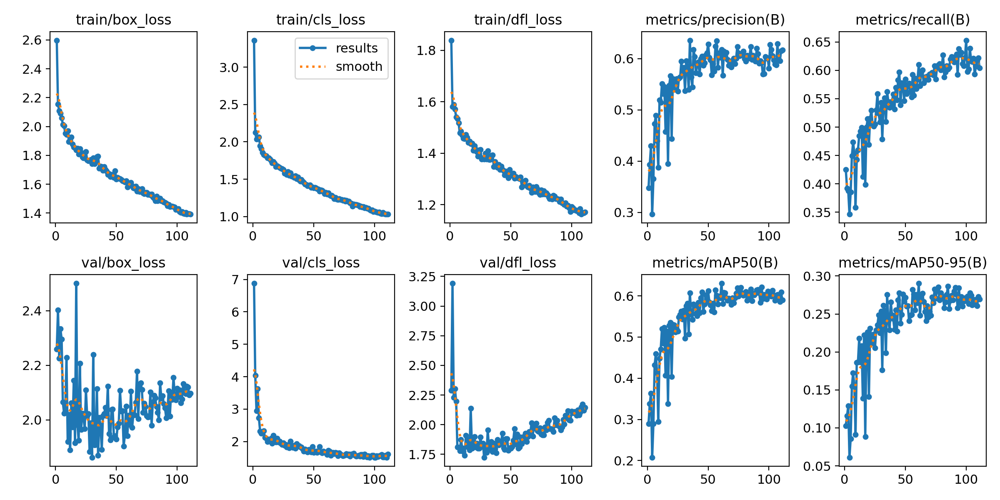

confusion_matrix.png


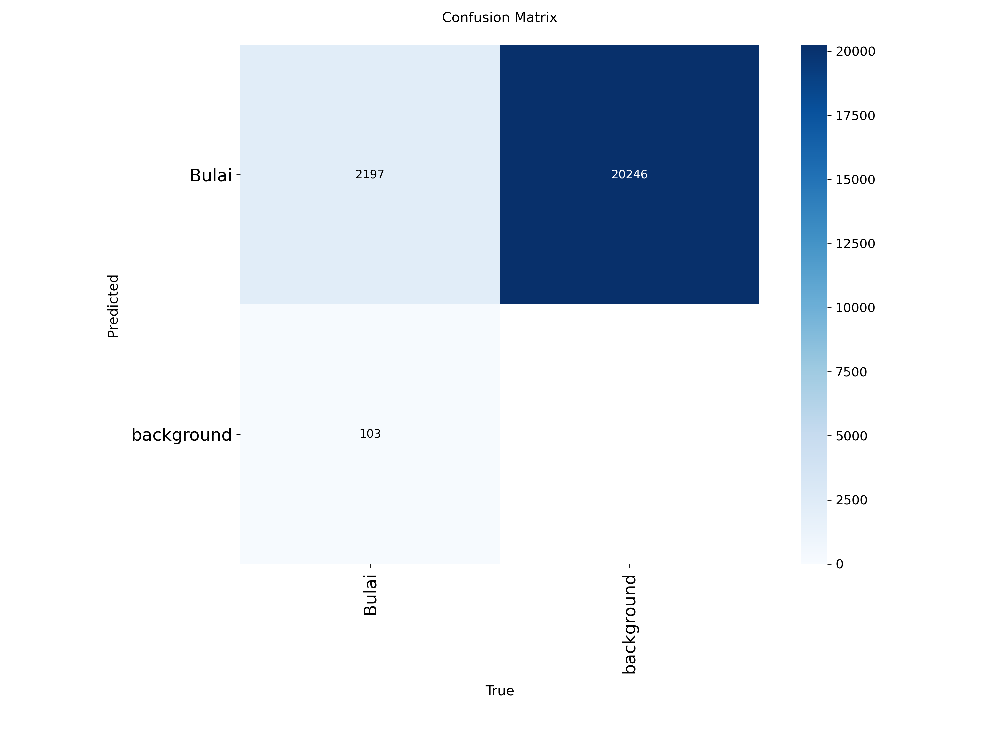

BoxPR_curve.png


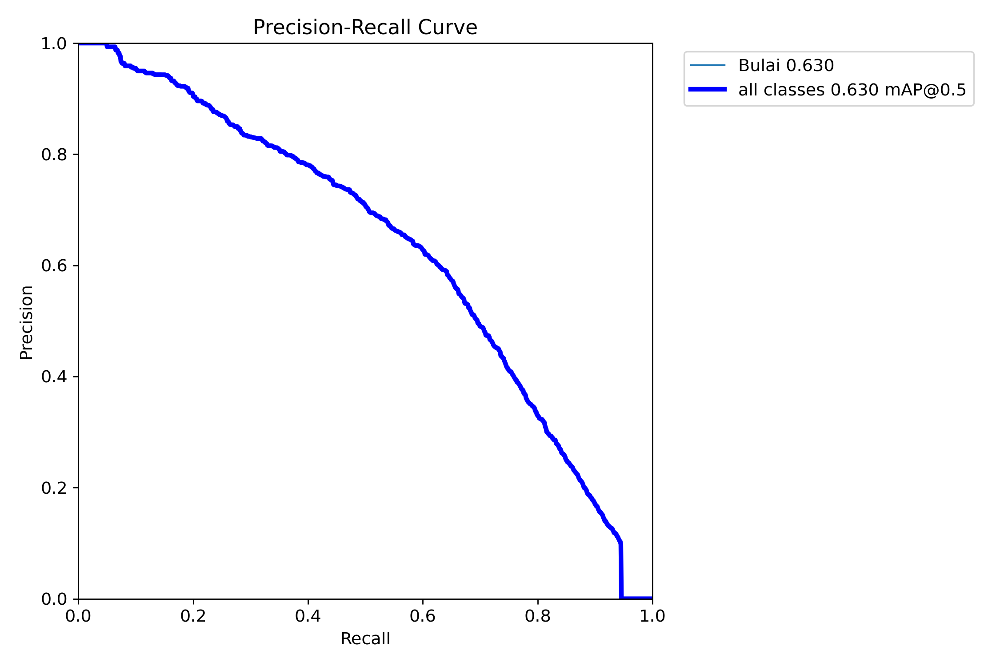

BoxF1_curve.png


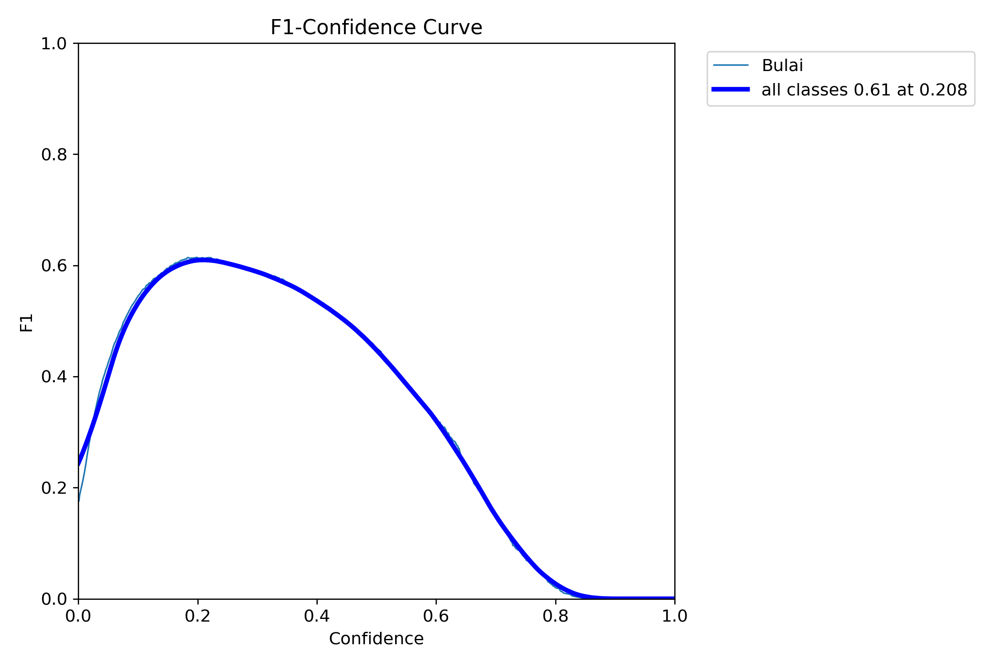

Ultralytics 8.4.174 🚀 Python-3.13.16 torch-2.11.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
Model summary (fused): 72 layers, 11,125,971 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 902.7±561.1 MB/s, size: 120.9 KB)
val: Scanning /content/dataset/valid/labels... 107 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 107/107 651.3it/s 0.2s
val: New cache created: /content/dataset/valid/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 7/7 23.4s/it 2:44
                   all        107       2300      0.621      0.607      0.631       0.29
Speed: 22.0ms preprocess, 1487.5ms inference, 0.0ms loss, 7.6ms postprocess per image
Ultralytics 8.4.174 🚀 Python-3.13.16 torch-2.11.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
Model summary (fused): 72 layers, 11,125,971 parameters, 0 gradients, 28.4 GFLOPs
WARNING ⚠️ val: Slow image access detected (ping: 0.0±0.0 ms, read: 18.7±8.1 MB/s, size: 115.7 

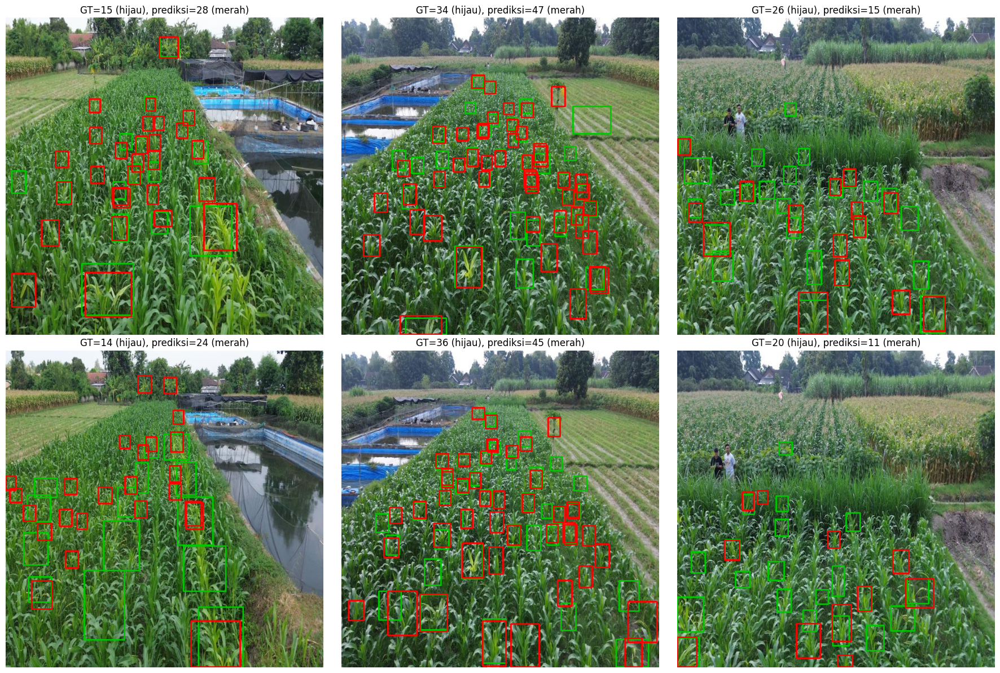

In [9]:
import os, glob, json
import numpy as np, cv2, pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display
from ultralytics import YOLO

RUN_DIR = f"{DRIVE_OUT}/{RUN_NAME}"
best = YOLO(f"{RUN_DIR}/weights/best.pt")

# ---------- 1. Grafik training (nama file sudah dibenarkan: BoxPR / BoxF1) ----------
for n in ["results.png", "confusion_matrix.png", "BoxPR_curve.png", "BoxF1_curve.png"]:
    p = f"{RUN_DIR}/{n}"
    if os.path.exists(p):
        print(n); display(Image(filename=p, width=800))
    else:
        print(f"(tidak ada: {n})")

# ---------- 2. Metrik valid & test, threshold dipilih dari VALID saja ----------
def run(split):
    return best.val(data=YAML_PATH, split=split, imgsz=IMGSZ, batch=BATCH,
                    plots=False, verbose=False)

vm, tm = run("val"), run("test")
f1v = np.array(vm.box.f1_curve).mean(0)
CONF = float(vm.box.px[int(f1v.argmax())])

rows = {}
for name, m in [("valid", vm), ("test", tm)]:
    i = int(np.abs(np.array(m.box.px) - CONF).argmin())
    p = float(np.array(m.box.p_curve).mean(0)[i])
    r = float(np.array(m.box.r_curve).mean(0)[i])
    rows[name] = {"conf": round(CONF, 3), "precision": p, "recall": r,
                  "f1": 2 * p * r / (p + r), "mAP50": float(m.box.map50),
                  "mAP50-95": float(m.box.map)}
df = pd.DataFrame(rows).T.round(3)
print("\n=== Ringkasan evaluasi (P, R, F1 pada conf dari valid; mAP pada conf rendah standar) ===")
print(df)
df.to_csv(f"{DRIVE_OUT}/{RUN_NAME}_evaluasi.csv")

# ---------- 3. Analisis kesalahan di data test ----------
imgs = sorted(glob.glob(f"{DATASET_DIR}/test/images/*"))
preds = best.predict(imgs, conf=CONF, imgsz=IMGSZ, verbose=False)

def gt_boxes(img_path):
    lp = img_path.replace("/images/", "/labels/").rsplit(".", 1)[0] + ".txt"
    return [list(map(float, l.split()[1:])) for l in open(lp) if l.strip()]

recs = []
for pth, r in zip(imgs, preds):
    g = gt_boxes(pth)
    recs.append((len(r.boxes) - len(g), pth, g, r))

n_pred = sum(len(r.boxes) for _, _, _, r in recs)
n_gt = sum(len(g) for _, _, g, _ in recs)
over = sum(d > 0 for d, *_ in recs); under = sum(d < 0 for d, *_ in recs)
print(f"\nTotal box prediksi={n_pred} vs ground truth={n_gt}")
print(f"Gambar over-detect={over}, under-detect={under}, pas={len(recs)-over-under}")

recs.sort(key=lambda x: -abs(x[0]))
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
for ax, (d, pth, g, r) in zip(axes.flat, recs[:6]):
    img = cv2.cvtColor(cv2.imread(pth), cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]
    for xc, yc, bw, bh in g:  # hijau = ground truth
        cv2.rectangle(img, (int((xc-bw/2)*w), int((yc-bh/2)*h)),
                      (int((xc+bw/2)*w), int((yc+bh/2)*h)), (0, 200, 0), 2)
    for x1, y1, x2, y2 in r.boxes.xyxy.cpu().numpy().astype(int):  # merah = prediksi
        cv2.rectangle(img, (x1, y1), (x2, y2), (255, 0, 0), 2)
    ax.imshow(img); ax.axis("off")
    ax.set_title(f"GT={len(g)} (hijau), prediksi={len(r.boxes)} (merah)")
plt.tight_layout(); plt.show()

# dipakai oleh sel contoh prediksi dan uji ONNX di bawah
BEST_CONF = CONF

## 5. Contoh prediksi
Beberapa foto test acak dengan hasil deteksi.

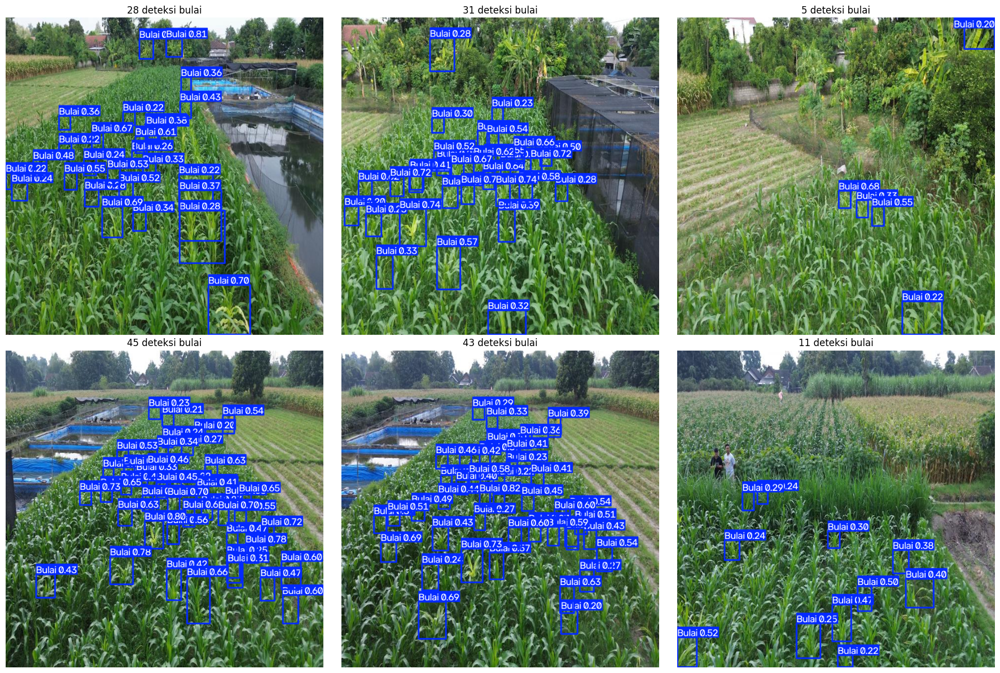

In [10]:
test_imgs = random.sample(glob.glob(f"{DATASET_DIR}/test/images/*"), 6)
preds = best.predict(test_imgs, conf=BEST_CONF, imgsz=IMGSZ, verbose=False)

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
for ax, res in zip(axes.flat, preds):
    ax.imshow(res.plot()[:, :, ::-1])
    ax.set_title(f"{len(res.boxes)} deteksi bulai"); ax.axis("off")
plt.tight_layout(); plt.show()

## 6. Ekspor ke ONNX dan verifikasi
Jalankan setelah bagian 4 (butuh `BEST_CONF`).

Sel ini mengekspor `best.pt` ke ONNX, membandingkan mAP, ukuran file, dan kecepatan antara `best.pt` dan ONNX di data test, lalu menyimpan `model_meta.json` untuk layanan AI. TFLite tidak diperlukan karena model dijalankan di server.

In [11]:
import os, json
import pandas as pd
from ultralytics import YOLO

WEIGHTS_DIR = f"{DRIVE_OUT}/{RUN_NAME}/weights"
best = YOLO(f"{WEIGHTS_DIR}/best.pt")

# ---------- 1. Ekspor ke ONNX (ukuran input tetap = IMGSZ saat training) ----------
onnx_path = best.export(format="onnx", imgsz=IMGSZ, simplify=True)
print("ONNX tersimpan di:", onnx_path)

# ---------- 2. Verifikasi: mAP di data test, best.pt vs ONNX ----------
onnx_model = YOLO(onnx_path, task="detect")
m_pt   = best.val(data=YAML_PATH, split="test", imgsz=IMGSZ, batch=16, plots=False, verbose=False)
m_onnx = onnx_model.val(data=YAML_PATH, split="test", imgsz=IMGSZ, batch=1, plots=False, verbose=False)

def baris(m, path):
    return {"precision": m.box.mp, "recall": m.box.mr,
            "mAP50": m.box.map50, "mAP50-95": m.box.map,
            "inferensi_ms": m.speed["inference"],
            "ukuran_MB": os.path.getsize(path) / 1e6}

df = pd.DataFrame({"best.pt": baris(m_pt, f"{WEIGHTS_DIR}/best.pt"),
                   "model.onnx": baris(m_onnx, onnx_path)}).T.round(4)
print("\n=== Perbandingan best.pt vs ONNX (data test) ===")
print(df)
selisih = abs(df.loc["best.pt", "mAP50"] - df.loc["model.onnx", "mAP50"])
print(f"\nSelisih mAP50: {selisih:.4f} -> {'OK (konversi aman)' if selisih < 0.01 else 'CEK ULANG ekspor'}")
df.to_csv(f"{DRIVE_OUT}/{RUN_NAME}_export_verifikasi.csv")

# ---------- 3. Metadata untuk layanan AI (dipakai saat integrasi backend) ----------
meta = {
    "model": MODEL_NAME,
    "task": "detect",
    "onnx_file": os.path.basename(onnx_path),
    "input_size": IMGSZ,
    "classes": ["Bulai"],
    "conf_threshold": float(globals().get("BEST_CONF", 0.2)),
}
meta_path = f"{WEIGHTS_DIR}/model_meta.json"
with open(meta_path, "w") as f:
    json.dump(meta, f, indent=2)
print("\nMetadata tersimpan di:", meta_path)
print(json.dumps(meta, indent=2))


Ultralytics 8.4.174 🚀 Python-3.13.16 torch-2.11.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino
Model summary (fused): 72 layers, 11,125,971 parameters, 0 gradients, 64.0 GFLOPs

PyTorch: starting from '/content/drive/MyDrive/CornGuard/training_bulai/bulai_yolov8s_960/weights/best.pt' with input shape (1, 3, 960, 960) BCHW and output shape(s) (1, 5, 18900) (21.5 MB)
requirements: Ultralytics requirements ['onnx>=1.12.0,<2.0.0', 'onnxruntime', 'onnxslim>=0.1.82'] not found, attempting AutoUpdate...
Using Python 3.13.16 environment at: /usr
Resolved 12 packages in 326ms
Prepared 4 packages in 553ms
Installed 4 packages in 39ms
 + colorama==0.4.6
 + onnx==1.23.2
 + onnxruntime==1.31.0
 + onnxslim==0.1.98

requirements: AutoUpdate success ✅ 1.3s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect


ONNX: starting export with onnx